In [3]:
#Load Dataset
import pandas as pd
from sklearn.datasets import load_iris

iris=load_iris()
df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
df['species']=iris.target
df['species']=df['species'].map({i: name for i, name in enumerate(iris.target_names)})
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
df.describe()
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


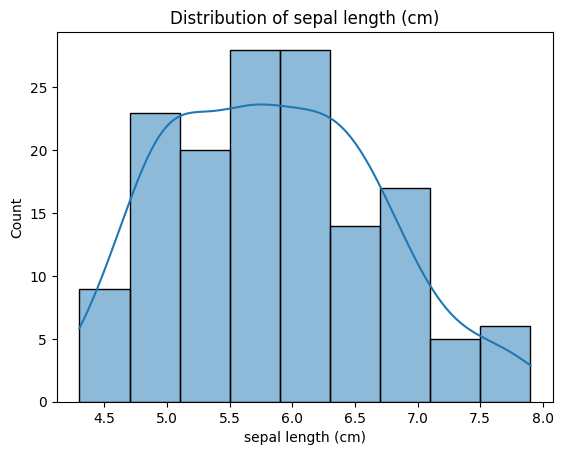

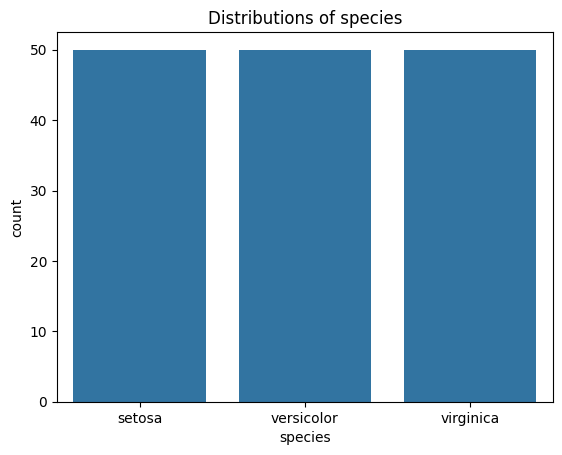

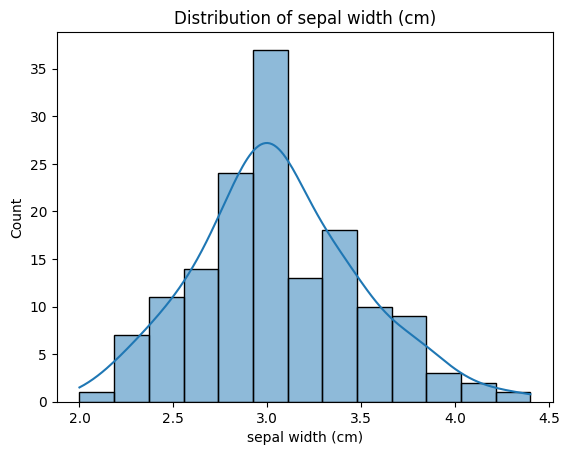

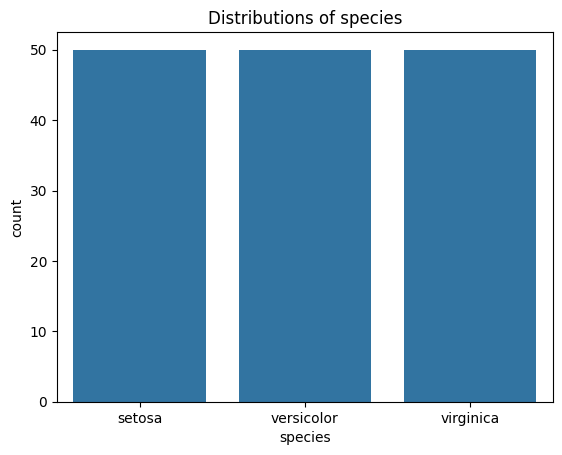

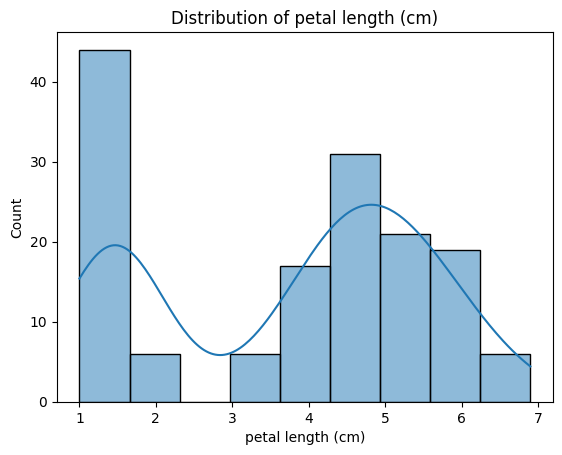

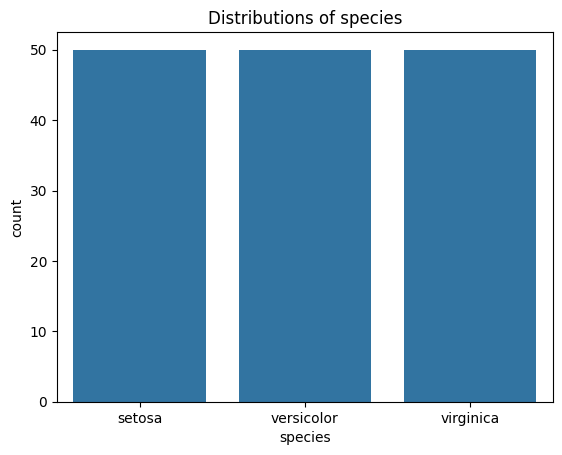

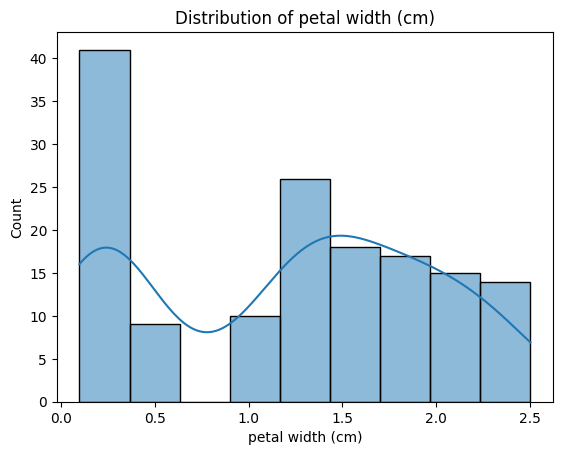

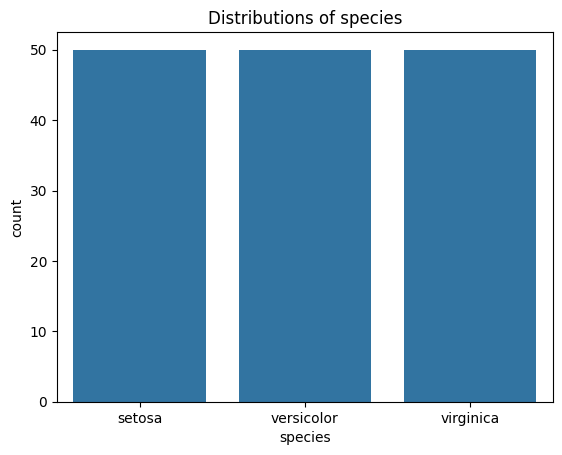

In [8]:
# Univariate analysis
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.columns[:-1]:
  sns.histplot(df[col],kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()

  sns.countplot(x='species',data=df)
  plt.title('Distributions of species')
  plt.show()

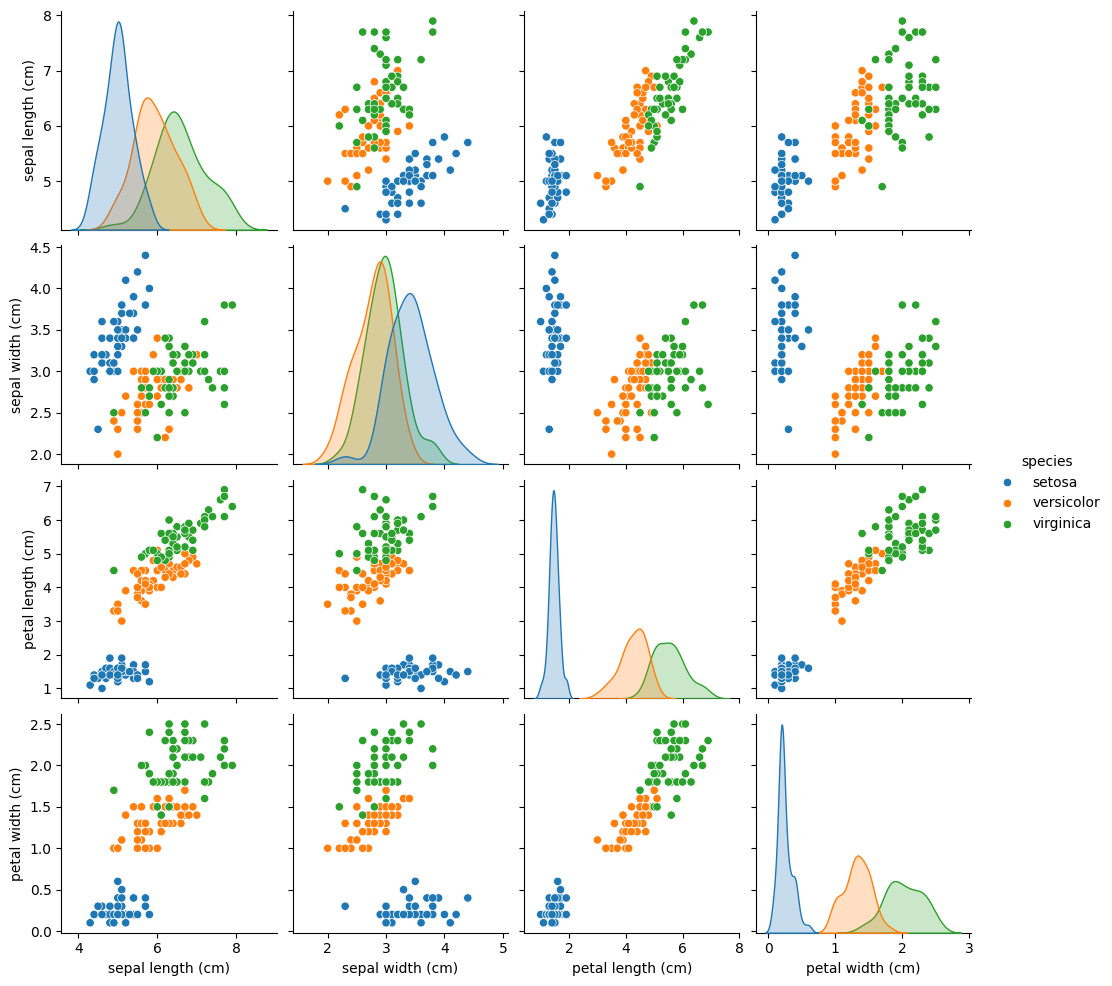

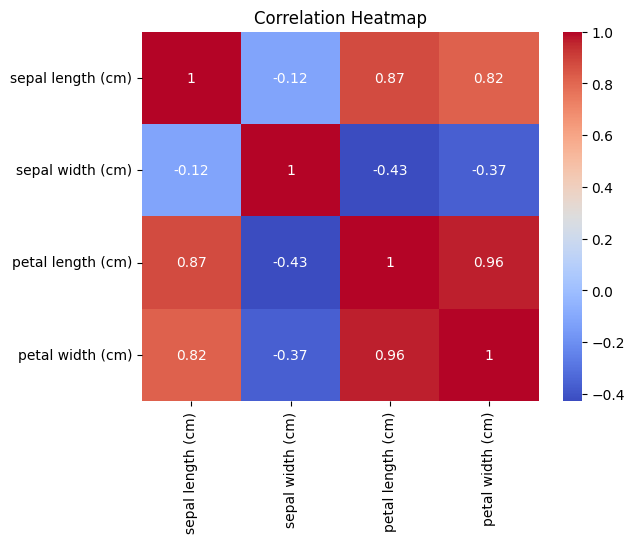

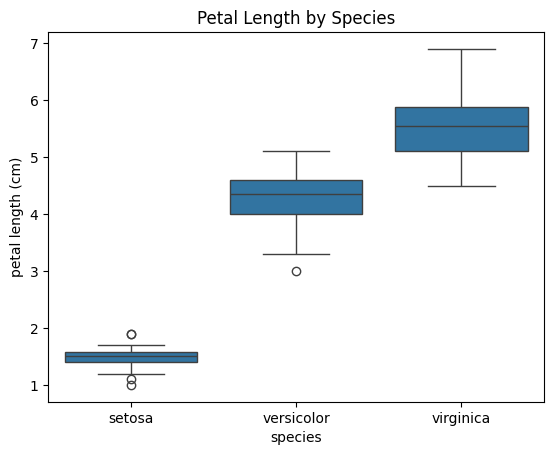

In [9]:
# Bivariate Analysis
# Pairplot to visualize relationships between variables
sns.pairplot(df, hue='species')
plt.show()

# Correlation heatmap
correlation_matrix = df.iloc[:, :-1].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Boxplot to compare petal length across species
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title('Petal Length by Species')
plt.show()

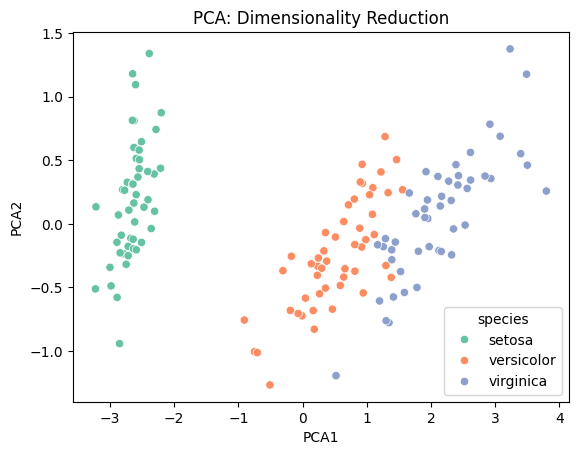

In [10]:
# Multivariate Analysis
# Using PCA for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df.iloc[:, :-1])
df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
df_pca['species'] = df['species']

# Scatter plot of PCA components
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='species', palette='Set2')
plt.title('PCA: Dimensionality Reduction')
plt.show()

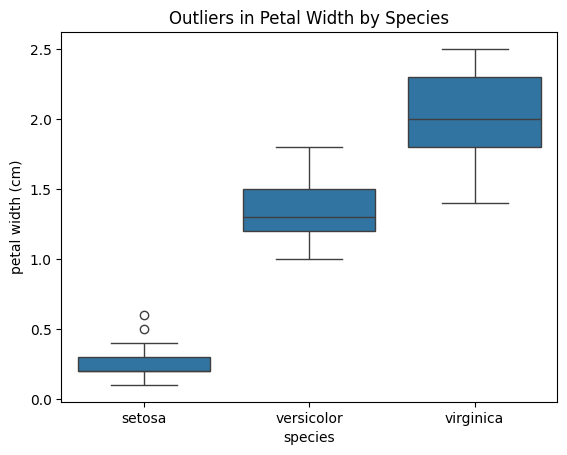

Outliers in Petal Width:
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), species, zscore_petal_width]
Index: []


In [11]:
# Identify patterns and anomalies
# Outliers in petal width using a boxplot
sns.boxplot(data=df, x='species', y='petal width (cm)')
plt.title('Outliers in Petal Width by Species')
plt.show()

# Example anomaly detection using Z-scores
from scipy.stats import zscore

df['zscore_petal_width'] = zscore(df['petal width (cm)'])
outliers = df[df['zscore_petal_width'].abs() > 3]
print("Outliers in Petal Width:")
print(outliers)

Distribution Insights:

Petal length and width are highly informative in distinguishing species. Sepal length and width overlap across species.

Relationships:

Positive correlation between petal length and width.

Outliers:

Not Detected potential outliers in petal width using Z-scores.